In [1]:
import pandas as pd
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_reviews.csv")
test = "This is a test"
print(word_tokenize(test))

C:\Users\Owner\Downloads
['This', 'is', 'a', 'test']


In [2]:
text = df["content"][0]
print(word_tokenize(text)) # the word_tokenize() function splits string into list of individual words

['Netflix', 'is', 'a', 'popular', 'streaming', 'app', 'with', 'a', 'wide', 'variety', 'of', 'movies', ',', 'series', ',', 'and', 'original', 'content', '.', 'The', 'interface', 'is', 'smooth', 'and', 'easy', 'to', 'use', ',', 'though', 'subscription', 'prices', 'can', 'be', 'a', 'bit', 'high', '.', 'Overall', ',', 'a', 'great', 'platform', 'for', 'entertainment', '.']


In [4]:
df[df['content'].isna() == True] # there are null values in the content column 

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
15615,6b66631b-6bc9-4d7e-adbf-77660acda47c,Cambria,NaN,1,1,9.11.1 build 10 62492,2025-04-20 00:16:34,9.11.1 build 10 62492
26022,5b06f098-6edd-4e7d-8a58-84f9a65f08e8,shenshi pang,NaN,3,0,8.31.1 build 14 50243,2025-01-03 11:50:11,8.31.1 build 14 50243
29654,3363e119-6469-4dd8-b6a2-9fc67c919e87,John Relles,NaN,5,0,8.132.2 build 18 50846,2024-12-02 02:54:46,8.132.2 build 18 50846
31091,49eda233-7487-41e6-8eb4-aeff02a906f0,Hetekia Kingi,NaN,5,0,8.138.1 build 10 50974,2024-11-10 03:49:25,8.138.1 build 10 50974
40172,a73c931f-5cce-4863-b1ae-40101455f137,Maria Wiley,NaN,5,0,8.114.0 build 19 50680,2024-05-21 16:56:29,8.114.0 build 19 50680
40523,839d55ed-ba9e-4753-a178-5799b9f86ffc,Myris Guilanda,NaN,2,0,NaN,2024-05-19 13:52:42,NaN


In [5]:
df = df.dropna(subset = ['content', 'score']) # dropping rows that have null values in content or score columns

In [6]:
df['tokens'] = df['content'].apply(word_tokenize) # makes a new column which has a list of all words in that rows content column 

In [7]:
all_words = [word for tokens in df['tokens'] for word in tokens] # creates list of every word from the content column, with repeats
len(all_words)

4427168

There are 4427168 total words in our content column

In [8]:
stop_words = set(stopwords.words("english")) # gets premade set of lowercase english stop words
punctuation = set(string.punctuation) # gets premade set of punctuation symbols
filtered_list = []

# removing stop words and punctuation symbols
for word in all_words:
    if word.lower() not in stop_words and word not in punctuation:
        filtered_list.append(word)

In [10]:
filtered_list[:10]

['Netflix',
 'popular',
 'streaming',
 'app',
 'wide',
 'variety',
 'movies',
 'series',
 'original',
 'content']

In [11]:
words_df = pd.DataFrame(filtered_list, columns = ['words']) # turning the list of words into a datafrmae
words_df.head(5)

,words
0,Netflix
1,popular
2,streaming
3,app
4,wide


In [12]:
words_df['words'].nunique() 

79233

In [13]:
counts = words_df['words'].value_counts().reset_index() # creating a dataframe number of times each word appears

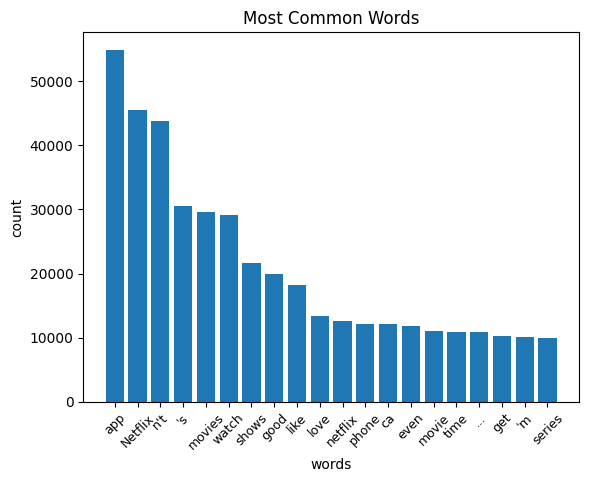

In [14]:
top_counts = counts.iloc[:20]

plt.bar(top_counts['words'], top_counts['count'])
plt.xticks(rotation = 45, fontsize = 9)
plt.xlabel('words')
plt.ylabel('count')
plt.title('Most Common Words')
plt.show()